# Advanced Logistic Regression and Extensions

Notebook ini membahas pengembangan lanjutan dari **Logistic Regression**, yaitu model regresi yang digunakan untuk masalah klasifikasi. Fokus chapter ini meliputi binary logistic regression, multiclass classification, regularization pada logistic regression, multilabel classification, model evaluation metrics, dan implementasi menggunakan scikit-learn.

Notebook ini disusun dalam Bahasa Indonesia dengan penjelasan teori, rumus matematis dalam format Markdown/LaTeX yang benar, contoh kode, visualisasi, dan interpretasi hasil.

## Tujuan Pembelajaran

Setelah mempelajari notebook ini, pembaca diharapkan mampu:

- Memahami konsep logistic regression untuk klasifikasi biner.
- Menjelaskan fungsi sigmoid dan log-odds.
- Menggunakan logistic regression pada dataset klasifikasi.
- Mengevaluasi model menggunakan confusion matrix, accuracy, precision, recall, F1-score, dan ROC-AUC.
- Membedakan multiclass classification dengan strategi One-vs-Rest dan multinomial logistic regression.
- Memahami regularization L1 dan L2 pada logistic regression.
- Mengimplementasikan multilabel classification.
- Memahami kapan accuracy tidak cukup untuk mengevaluasi model.
- Menggunakan pipeline dan scikit-learn untuk membangun workflow klasifikasi yang rapi.

## Persiapan Library

Dataset yang digunakan berasal dari scikit-learn, yaitu Breast Cancer dataset, Iris dataset, dan dataset sintetis multilabel. Visualisasi dibuat menggunakan matplotlib agar notebook tetap mudah dijalankan.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from sklearn.datasets import load_breast_cancer, load_iris, make_multilabel_classification
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    multilabel_confusion_matrix,
    hamming_loss
)

np.random.seed(2024)
pd.set_option("display.max_columns", 120)

## Ringkasan Chapter

Logistic regression merupakan metode klasifikasi yang memodelkan probabilitas suatu data masuk ke kelas tertentu. Berbeda dari linear regression yang memprediksi nilai kontinu, logistic regression memprediksi probabilitas kelas.

Chapter ini memperluas logistic regression ke beberapa konteks:

| Topik | Inti Pembahasan |
|---|---|
| Binary logistic regression | Klasifikasi dua kelas dengan sigmoid |
| Multiclass classification | Klasifikasi lebih dari dua kelas |
| One-vs-Rest | Melatih satu classifier biner untuk setiap kelas |
| Multinomial logistic regression | Menggunakan softmax untuk memodelkan probabilitas banyak kelas sekaligus |
| Regularization | Mengurangi overfitting dengan penalti L1 atau L2 |
| Multilabel classification | Satu data dapat memiliki lebih dari satu label |
| Model evaluation | Menggunakan metrik yang sesuai dengan konteks masalah |

## Overview of Logistic Regression

Logistic regression digunakan untuk masalah klasifikasi. Pada kasus biner, target hanya memiliki dua kelas, misalnya:

- Spam atau bukan spam
- Malignant atau benign
- Fraud atau bukan fraud
- Lulus atau tidak lulus

Model ini memulai prosesnya dengan kombinasi linear dari fitur, lalu mengubah output linear tersebut menjadi probabilitas menggunakan fungsi sigmoid. Nilai probabilitas kemudian dibandingkan dengan threshold, biasanya 0.5, untuk menentukan kelas akhir.

## Rumus Linear Combination

Sebelum masuk ke fungsi sigmoid, logistic regression menghitung skor linear:

$$
z = \beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_nx_n
$$

Keterangan:

- $z$ = skor linear sebelum diubah menjadi probabilitas
- $\beta_0$ = intercept atau bias
- $\beta_i$ = koefisien fitur ke-$i$
- $x_i$ = nilai fitur ke-$i$
- $n$ = jumlah fitur

Skor $z$ dapat bernilai dari negatif tak hingga sampai positif tak hingga. Karena klasifikasi membutuhkan probabilitas, skor ini perlu diubah ke rentang 0 sampai 1.

## Rumus Sigmoid Function

Fungsi sigmoid digunakan untuk mengubah skor linear menjadi probabilitas.

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Dengan memasukkan skor linear ke dalam sigmoid:

$$
P(Y=1|X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_nx_n)}}
$$

Keterangan:

- $P(Y=1|X)$ = probabilitas data masuk ke kelas positif
- $e$ = bilangan Euler
- $z$ = skor linear

Jika probabilitas lebih besar dari threshold, data diprediksi sebagai kelas positif. Jika tidak, data diprediksi sebagai kelas negatif.

## Rumus Log-Odds

Logistic regression juga dapat dipahami melalui konsep odds dan log-odds.

Odds adalah rasio probabilitas suatu event terjadi dibandingkan tidak terjadi:

$$
Odds = \frac{p}{1-p}
$$

Log-odds adalah logaritma natural dari odds:

$$
\log\left(\frac{p}{1-p}\right)
=
\beta_0 + \beta_1x_1 + \beta_2x_2 + \cdots + \beta_nx_n
$$

Keterangan:

- $p$ = probabilitas kelas positif
- $\frac{p}{1-p}$ = odds
- $\log\left(\frac{p}{1-p}\right)$ = log-odds

Artinya, logistic regression sebenarnya memodelkan log-odds sebagai kombinasi linear dari fitur.

## Load Breast Cancer Dataset

Breast Cancer dataset digunakan untuk demonstrasi binary logistic regression. Target dataset ini terdiri dari dua kelas, yaitu malignant dan benign.

In [36]:
cancer = load_breast_cancer()

X = cancer.data
y = cancer.target

df_cancer = pd.DataFrame(X, columns=cancer.feature_names)
df_cancer["target"] = y
df_cancer["target_name"] = df_cancer["target"].map({0: "malignant", 1: "benign"})

print("Shape dataset:", df_cancer.shape)
print("Target names:", cancer.target_names)
df_cancer.head()

Shape dataset: (569, 32)
Target names: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


## Distribusi Target

Sebelum modeling, distribusi target perlu diperiksa. Jika dataset tidak seimbang, accuracy saja bisa menyesatkan.

target_name
benign       357
malignant    212
Name: count, dtype: int64

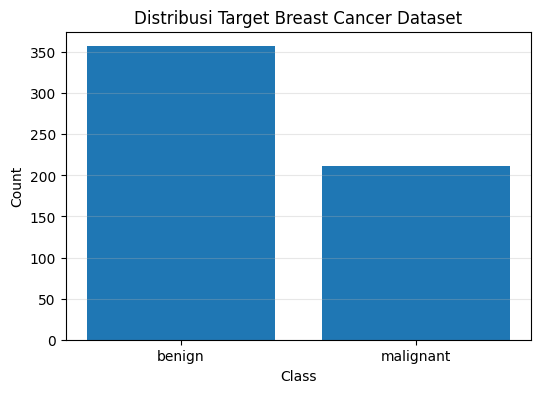

In [37]:
target_counts = df_cancer["target_name"].value_counts()

display(target_counts)

plt.figure(figsize=(6, 4))
plt.bar(target_counts.index, target_counts.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Distribusi Target Breast Cancer Dataset")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Train-Test Split dan Pipeline

Logistic regression cukup sensitif terhadap skala fitur, terutama jika menggunakan regularization. Karena itu, `StandardScaler` digunakan dalam pipeline sebelum model logistic regression.

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2024,
    stratify=y
)

binary_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=10000))
])

binary_pipe.fit(X_train, y_train)

y_pred = binary_pipe.predict(X_test)
y_proba = binary_pipe.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9649122807017544


## Confusion Matrix

Confusion matrix menunjukkan jumlah prediksi benar dan salah untuk setiap kelas.

Untuk klasifikasi biner, terdapat empat istilah utama:

| Istilah | Penjelasan |
|---|---|
| True Positive (TP) | Data positif diprediksi positif |
| True Negative (TN) | Data negatif diprediksi negatif |
| False Positive (FP) | Data negatif salah diprediksi positif |
| False Negative (FN) | Data positif salah diprediksi negatif |

Pada kasus medis, false negative sering lebih berbahaya karena pasien yang sebenarnya sakit bisa diprediksi tidak sakit.

,Predicted malignant,Predicted benign
True malignant,39,3
True benign,1,71


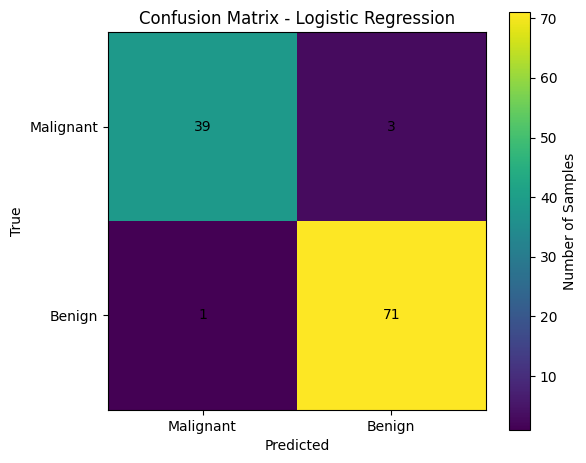

In [39]:
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=["True malignant", "True benign"],
    columns=["Predicted malignant", "Predicted benign"]
)

display(cm_df)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks([0, 1], ["Malignant", "Benign"])
plt.yticks([0, 1], ["Malignant", "Benign"])
plt.colorbar(label="Number of Samples")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

## Rumus Metrik Evaluasi Klasifikasi

### Accuracy

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

Accuracy mengukur proporsi prediksi yang benar dari seluruh data.

### Precision

$$
Precision = \frac{TP}{TP + FP}
$$

Precision menjawab pertanyaan: dari semua prediksi positif, berapa yang benar-benar positif?

### Recall

$$
Recall = \frac{TP}{TP + FN}
$$

Recall menjawab pertanyaan: dari semua data positif aktual, berapa yang berhasil ditemukan?

### F1-Score

$$
F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}
$$

F1-score digunakan untuk menyeimbangkan precision dan recall.

In [40]:
report = classification_report(
    y_test,
    y_pred,
    target_names=cancer.target_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
malignant,0.975000,0.928571,0.951220,42.000000
benign,0.959459,0.986111,0.972603,72.000000
accuracy,0.964912,0.964912,0.964912,0.964912
macro avg,0.967230,0.957341,0.961911,114.000000
weighted avg,0.965185,0.964912,0.964725,114.000000


## Analisis Logistic Regression Biner

Model logistic regression dapat memberikan performa yang baik pada Breast Cancer dataset. Namun, pada konteks medis, accuracy bukan satu-satunya metrik penting. Recall untuk kelas malignant perlu diperhatikan karena false negative dapat berdampak serius.

Metrik yang lebih tepat bergantung pada tujuan:

- Jika ingin meminimalkan pasien sakit yang terlewat, gunakan recall.
- Jika ingin meminimalkan prediksi sakit yang salah, gunakan precision.
- Jika ingin menyeimbangkan keduanya, gunakan F1-score.

## ROC Curve dan AUC

ROC curve menunjukkan hubungan antara True Positive Rate dan False Positive Rate pada berbagai threshold.

### True Positive Rate

$$
TPR = \frac{TP}{TP + FN}
$$

### False Positive Rate

$$
FPR = \frac{FP}{FP + TN}
$$

AUC mengukur luas area di bawah ROC curve. Nilai AUC mendekati 1 menunjukkan model sangat baik dalam membedakan kelas.

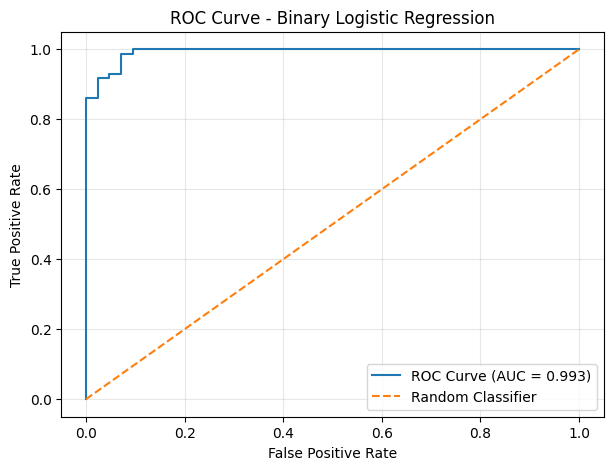

In [41]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Binary Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Multiclass Classification Techniques

Binary logistic regression hanya menangani dua kelas. Untuk kasus yang memiliki lebih dari dua kelas, logistic regression dapat diperluas menggunakan dua pendekatan utama:

1. **One-vs-Rest (OvR)**
2. **Multinomial Logistic Regression**

Dataset Iris digunakan karena memiliki tiga kelas: setosa, versicolor, dan virginica.

## One-vs-Rest Logistic Regression

Pada One-vs-Rest, model melatih satu classifier biner untuk setiap kelas.

Jika terdapat $K$ kelas, maka akan dilatih $K$ classifier:

$$
Classifier_k: Class\ k\ vs\ All\ Other\ Classes
$$

Saat prediksi, model memilih kelas dengan confidence score tertinggi:

$$
\hat{y} = \arg\max_{k} score_k(x)
$$

Keterangan:

- $K$ = jumlah kelas
- $score_k(x)$ = skor model untuk kelas ke-$k$
- $\hat{y}$ = kelas prediksi akhir

## Multinomial Logistic Regression dan Softmax

Multinomial logistic regression memodelkan probabilitas semua kelas secara bersamaan menggunakan fungsi softmax.

$$
P(Y=k|X) =
\frac{e^{z_k}}{\sum_{j=1}^{K}e^{z_j}}
$$

Keterangan:

- $P(Y=k|X)$ = probabilitas data masuk ke kelas ke-$k$
- $z_k$ = skor linear untuk kelas ke-$k$
- $K$ = jumlah kelas

Prediksi akhir dipilih berdasarkan probabilitas terbesar:

$$
\hat{y} = \arg\max_k P(Y=k|X)
$$

Pendekatan multinomial cocok ketika kelas bersifat mutually exclusive, yaitu satu data hanya boleh masuk ke satu kelas.

## Load Iris Dataset

Iris dataset memiliki 150 data, 4 fitur numerik, dan 3 kelas target.

In [42]:
iris = load_iris()

X_iris = iris.data
y_iris = iris.target

df_iris = pd.DataFrame(X_iris, columns=iris.feature_names)
df_iris["target"] = y_iris
df_iris["target_name"] = df_iris["target"].map({i: name for i, name in enumerate(iris.target_names)})

print("Shape Iris:", df_iris.shape)
print("Target names:", iris.target_names)
df_iris.head()

Shape Iris: (150, 6)
Target names: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## Visualisasi Iris Dataset

Visualisasi berikut memakai dua fitur yang biasanya paling informatif, yaitu petal length dan petal width.

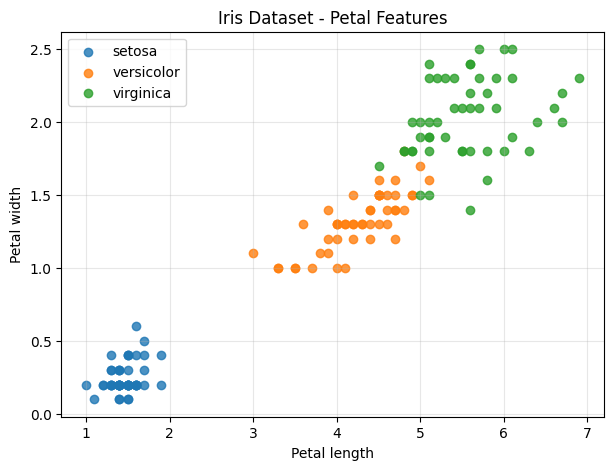

In [43]:
plt.figure(figsize=(7, 5))

for class_idx, class_name in enumerate(iris.target_names):
    mask = y_iris == class_idx
    plt.scatter(
        X_iris[mask, 2],
        X_iris[mask, 3],
        label=class_name,
        alpha=0.8
    )

plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title("Iris Dataset - Petal Features")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Implementasi OvR dan Multinomial Logistic Regression

Kedua pendekatan akan dilatih dan dibandingkan menggunakan dataset Iris.

In [44]:
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris,
    y_iris,
    test_size=0.3,
    random_state=2024,
    stratify=y_iris
)

ovr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(solver="liblinear", max_iter=1000))
])

multinomial_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(solver="lbfgs", max_iter=1000))
])

ovr_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", OneVsRestClassifier(
        LogisticRegression(solver="liblinear", max_iter=1000)
    ))
])

multinomial_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(solver="lbfgs", max_iter=1000))
])

ovr_pipe.fit(X_train_i, y_train_i)
multinomial_pipe.fit(X_train_i, y_train_i)

y_pred_ovr = ovr_pipe.predict(X_test_i)
y_pred_multinomial = multinomial_pipe.predict(X_test_i)

print("OvR Accuracy:", accuracy_score(y_test_i, y_pred_ovr))
print("Multinomial Accuracy:", accuracy_score(y_test_i, y_pred_multinomial))

OvR Accuracy: 0.9333333333333333
Multinomial Accuracy: 0.9555555555555556


In [45]:
report_ovr = pd.DataFrame(
    classification_report(
        y_test_i,
        y_pred_ovr,
        target_names=iris.target_names,
        output_dict=True
    )
).transpose()

report_multinomial = pd.DataFrame(
    classification_report(
        y_test_i,
        y_pred_multinomial,
        target_names=iris.target_names,
        output_dict=True
    )
).transpose()

print("One-vs-Rest Logistic Regression")
display(report_ovr)

print("Multinomial Logistic Regression")
display(report_multinomial)

One-vs-Rest Logistic Regression


,precision,recall,f1-score,support
setosa,1.000000,1.000000,1.000000,15.000000
versicolor,0.928571,0.866667,0.896552,15.000000
virginica,0.875000,0.933333,0.903226,15.000000
accuracy,0.933333,0.933333,0.933333,0.933333
macro avg,0.934524,0.933333,0.933259,45.000000
weighted avg,0.934524,0.933333,0.933259,45.000000


Multinomial Logistic Regression


,precision,recall,f1-score,support
setosa,1.000000,1.000000,1.000000,15.000000
versicolor,0.933333,0.933333,0.933333,15.000000
virginica,0.933333,0.933333,0.933333,15.000000
accuracy,0.955556,0.955556,0.955556,0.955556
macro avg,0.955556,0.955556,0.955556,45.000000
weighted avg,0.955556,0.955556,0.955556,45.000000


## Analisis OvR dan Multinomial

OvR memecah masalah multiclass menjadi beberapa masalah biner. Pendekatan ini sederhana dan fleksibel. Multinomial logistic regression mengoptimalkan probabilitas semua kelas secara bersamaan, sehingga lebih natural untuk kasus multiclass yang kelasnya mutually exclusive.

Pada dataset kecil seperti Iris, performa keduanya bisa sangat mirip. Perbedaan lebih terlihat pada dataset yang lebih besar atau kelas yang lebih kompleks.

## Decision Boundary Sederhana

Decision boundary berikut dibuat hanya menggunakan dua fitur petal agar dapat divisualisasikan dalam 2D.

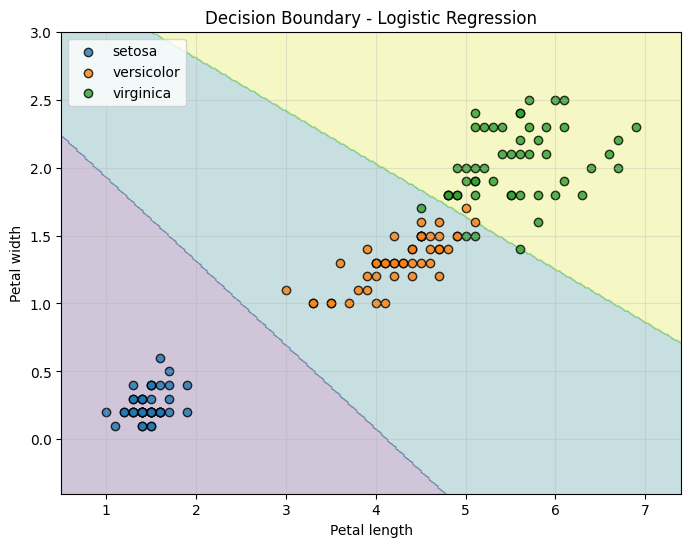

In [46]:
X_iris_2d = X_iris[:, [2, 3]]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_iris_2d,
    y_iris,
    test_size=0.3,
    random_state=2024,
    stratify=y_iris
)

boundary_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

boundary_model.fit(X_train_2d, y_train_2d)

x_min, x_max = X_iris_2d[:, 0].min() - 0.5, X_iris_2d[:, 0].max() + 0.5
y_min, y_max = X_iris_2d[:, 1].min() - 0.5, X_iris_2d[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = boundary_model.predict(grid_points).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.25)

for class_idx, class_name in enumerate(iris.target_names):
    mask = y_iris == class_idx
    plt.scatter(
        X_iris_2d[mask, 0],
        X_iris_2d[mask, 1],
        label=class_name,
        edgecolor="black",
        alpha=0.8
    )

plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.title("Decision Boundary - Logistic Regression")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Regularization in Logistic Regression

Logistic regression juga dapat menggunakan regularization untuk mencegah overfitting. Dua jenis regularization yang umum adalah:

- L2 regularization atau Ridge
- L1 regularization atau Lasso

Pada scikit-learn, kekuatan regularization dikontrol oleh parameter `C`.

Berbeda dari `alpha` pada Ridge/Lasso regression, parameter `C` adalah kebalikan dari kekuatan regularization:

$$
C = \frac{1}{\lambda}
$$

Artinya:

- Nilai $C$ kecil = regularization lebih kuat
- Nilai $C$ besar = regularization lebih lemah

## Rumus Loss Logistic Regression

Untuk binary logistic regression, loss yang umum digunakan adalah binary cross-entropy atau log loss.

$$
Loss =
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i \log(\hat{p}_i)
+
(1-y_i)\log(1-\hat{p}_i)
\right]
$$

Keterangan:

- $y_i$ = label aktual, bernilai 0 atau 1
- $\hat{p}_i$ = probabilitas prediksi untuk kelas positif
- $n$ = jumlah data

Loss ini memberi penalti besar jika model sangat yakin pada prediksi yang salah.

## Rumus L2 Regularized Logistic Regression

L2 regularization menambahkan penalti kuadrat koefisien.

$$
Loss_{L2}
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i \log(\hat{p}_i)
+
(1-y_i)\log(1-\hat{p}_i)
\right]
+
\lambda \sum_{j=1}^{p}\beta_j^2
$$

Keterangan:

- $\lambda$ = kekuatan regularization
- $\beta_j$ = koefisien fitur ke-$j$
- $p$ = jumlah fitur

L2 mengecilkan koefisien, tetapi jarang membuatnya tepat menjadi nol.

## Rumus L1 Regularized Logistic Regression

L1 regularization menambahkan penalti nilai absolut koefisien.

$$
Loss_{L1}
=
-\frac{1}{n}
\sum_{i=1}^{n}
\left[
y_i \log(\hat{p}_i)
+
(1-y_i)\log(1-\hat{p}_i)
\right]
+
\lambda \sum_{j=1}^{p}|\beta_j|
$$

L1 dapat membuat sebagian koefisien menjadi nol, sehingga dapat digunakan sebagai bentuk feature selection.

## Implementasi Regularized Logistic Regression

Dataset Breast Cancer digunakan kembali. Kali ini model dibandingkan antara L2 dan L1 regularization.

In [47]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=2024,
    stratify=y
)

ridge_logit_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(penalty="l2", solver="liblinear", C=0.1, max_iter=10000))
])

lasso_logit_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(penalty="l1", solver="liblinear", C=0.1, max_iter=10000))
])

ridge_logit_pipe.fit(X_train_c, y_train_c)
lasso_logit_pipe.fit(X_train_c, y_train_c)

y_pred_ridge = ridge_logit_pipe.predict(X_test_c)
y_pred_lasso = lasso_logit_pipe.predict(X_test_c)

regularized_results = pd.DataFrame({
    "Model": ["L2 Logistic Regression", "L1 Logistic Regression"],
    "Accuracy": [
        accuracy_score(y_test_c, y_pred_ridge),
        accuracy_score(y_test_c, y_pred_lasso)
    ],
    "Precision": [
        precision_score(y_test_c, y_pred_ridge),
        precision_score(y_test_c, y_pred_lasso)
    ],
    "Recall": [
        recall_score(y_test_c, y_pred_ridge),
        recall_score(y_test_c, y_pred_lasso)
    ],
    "F1-score": [
        f1_score(y_test_c, y_pred_ridge),
        f1_score(y_test_c, y_pred_lasso)
    ]
})

regularized_results

,Model,Accuracy,Precision,Recall,F1-score
0,L2 Logistic Regression,0.982456,0.981481,0.990654,0.986047
1,L1 Logistic Regression,0.964912,0.980952,0.962617,0.971698


## Analisis Regularization

L2 cenderung mempertahankan semua fitur, tetapi mengecilkan koefisien. L1 dapat membuat koefisien tertentu menjadi nol. Karena itu, L1 sering berguna ketika banyak fitur tidak relevan atau ingin model yang lebih sparse.

Pemilihan L1 atau L2 tidak cukup hanya berdasarkan accuracy. Pada kasus medis, recall untuk kelas tertentu mungkin lebih penting daripada accuracy total.

## Coefficient Path untuk C

Plot berikut menunjukkan bagaimana koefisien berubah ketika nilai `C` berubah. Karena `C` adalah inverse regularization strength, semakin besar `C`, semakin lemah regularization.

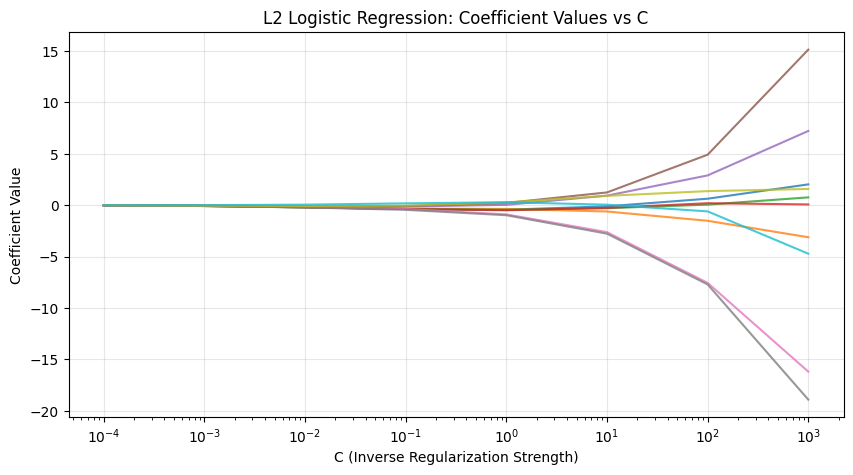

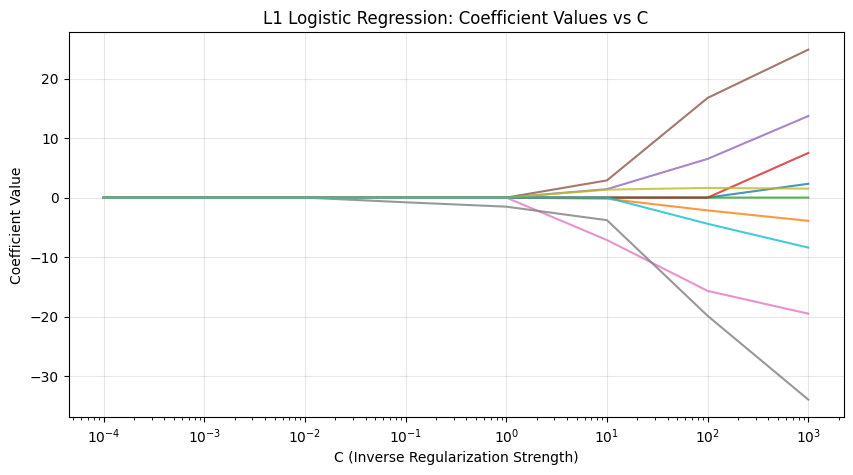

In [48]:
C_values = np.array([0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_c)

coefs_l2 = []
coefs_l1 = []

for C in C_values:
    l2_model = LogisticRegression(penalty="l2", solver="liblinear", C=C, max_iter=10000)
    l1_model = LogisticRegression(penalty="l1", solver="liblinear", C=C, max_iter=10000)

    l2_model.fit(X_train_scaled, y_train_c)
    l1_model.fit(X_train_scaled, y_train_c)

    coefs_l2.append(l2_model.coef_[0])
    coefs_l1.append(l1_model.coef_[0])

coefs_l2 = np.array(coefs_l2)
coefs_l1 = np.array(coefs_l1)

plt.figure(figsize=(10, 5))
for i in range(min(10, X.shape[1])):
    plt.plot(C_values, coefs_l2[:, i], alpha=0.8)
plt.xscale("log")
plt.xlabel("C (Inverse Regularization Strength)")
plt.ylabel("Coefficient Value")
plt.title("L2 Logistic Regression: Coefficient Values vs C")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
for i in range(min(10, X.shape[1])):
    plt.plot(C_values, coefs_l1[:, i], alpha=0.8)
plt.xscale("log")
plt.xlabel("C (Inverse Regularization Strength)")
plt.ylabel("Coefficient Value")
plt.title("L1 Logistic Regression: Coefficient Values vs C")
plt.grid(alpha=0.3)
plt.show()

## Grid Search untuk Regularization Strength

Nilai `C` sebaiknya dipilih dengan validasi, bukan ditebak secara manual. Contoh berikut menggunakan `GridSearchCV`.

In [49]:
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"]
}

grid_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(solver="liblinear", max_iter=10000))
])

grid = GridSearchCV(
    grid_pipe,
    param_grid,
    cv=5,
    scoring="f1"
)

grid.fit(X_train_c, y_train_c)

print("Best parameters:", grid.best_params_)
print("Best CV F1:", grid.best_score_)
print("Test F1:", f1_score(y_test_c, grid.predict(X_test_c)))

Best parameters: {'model__C': 1, 'model__penalty': 'l2'}
Best CV F1: 0.9861743572415496
Test F1: 0.9767441860465116


## Multilabel Classification Concepts

Pada multiclass classification, satu data hanya memiliki satu label dari beberapa kelas. Pada multilabel classification, satu data dapat memiliki beberapa label sekaligus.

Contoh multilabel:

- Artikel berita dapat memiliki label `politik`, `ekonomi`, dan `internasional` sekaligus.
- Gambar dapat memiliki label `mobil`, `jalan`, dan `pohon`.
- Lagu dapat memiliki label `pop`, `acoustic`, dan `sad`.

Multilabel classification dapat dilakukan dengan melatih satu classifier untuk setiap label.

## Rumus Prediksi Multilabel

Jika terdapat $L$ label, maka model menghasilkan prediksi biner untuk setiap label:

$$
\hat{y} =
[\hat{y}_1, \hat{y}_2, \ldots, \hat{y}_L]
$$

Untuk setiap label ke-$l$:

$$
\hat{y}_l =
\begin{cases}
1, & \text{jika } P(Y_l=1|X) > threshold \\
0, & \text{jika } P(Y_l=1|X) \le threshold
\end{cases}
$$

Keterangan:

- $L$ = jumlah label
- $\hat{y}_l$ = prediksi untuk label ke-$l$
- $threshold$ = batas probabilitas, biasanya 0.5

## Membuat Dataset Multilabel

Dataset sintetis dibuat menggunakan `make_multilabel_classification`. Dataset ini memiliki beberapa label untuk setiap data.

In [50]:
X_multi, y_multi = make_multilabel_classification(
    n_samples=1000,
    n_features=20,
    n_classes=5,
    n_labels=2,
    random_state=2024
)

df_multi = pd.DataFrame(X_multi, columns=[f"feature_{i}" for i in range(X_multi.shape[1])])
for i in range(y_multi.shape[1]):
    df_multi[f"label_{i}"] = y_multi[:, i]

print("Shape fitur:", X_multi.shape)
print("Shape label:", y_multi.shape)
df_multi.head()

Shape fitur: (1000, 20)
Shape label: (1000, 5)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,label_0,label_1,label_2,label_3,label_4
0,1.0,2.0,2.0,2.0,4.0,4.0,5.0,0.0,6.0,2.0,4.0,0.0,2.0,2.0,1.0,2.0,0.0,2.0,6.0,5.0,0,1,0,0,0
1,4.0,2.0,1.0,1.0,1.0,3.0,2.0,5.0,2.0,4.0,3.0,4.0,4.0,2.0,3.0,1.0,2.0,4.0,1.0,3.0,0,0,0,0,0
2,1.0,4.0,1.0,1.0,4.0,4.0,6.0,2.0,4.0,4.0,5.0,5.0,2.0,1.0,1.0,3.0,1.0,5.0,4.0,3.0,0,1,1,0,0
3,0.0,0.0,0.0,6.0,1.0,2.0,0.0,5.0,6.0,0.0,5.0,5.0,3.0,2.0,3.0,2.0,0.0,4.0,0.0,2.0,0,0,1,0,0
4,4.0,3.0,0.0,1.0,6.0,6.0,2.0,0.0,2.0,1.0,5.0,2.0,1.0,2.0,3.0,2.0,3.0,3.0,5.0,3.0,1,1,0,0,1


## Distribusi Label Multilabel

Pada multilabel classification, satu sampel bisa memiliki lebih dari satu label. Karena itu, distribusi tiap label perlu diperiksa secara terpisah.

label_0    554
label_1    616
label_2    298
label_3    116
label_4    318
dtype: int64

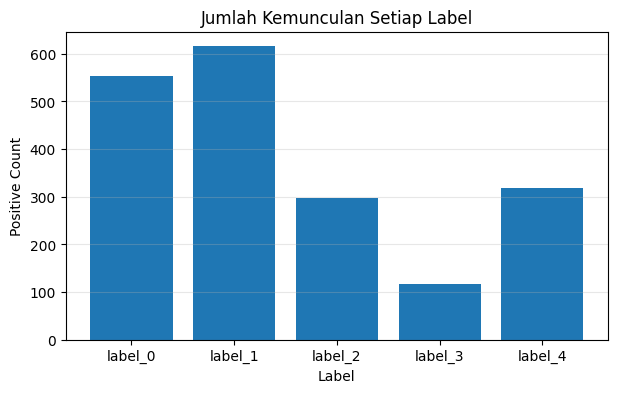

In [51]:
label_counts = pd.DataFrame(y_multi, columns=[f"label_{i}" for i in range(y_multi.shape[1])]).sum()

display(label_counts)

plt.figure(figsize=(7, 4))
plt.bar(label_counts.index, label_counts.values)
plt.xlabel("Label")
plt.ylabel("Positive Count")
plt.title("Jumlah Kemunculan Setiap Label")
plt.grid(axis="y", alpha=0.3)
plt.show()

## Implementasi Multilabel Logistic Regression dengan OneVsRestClassifier

Scikit-learn menyediakan `OneVsRestClassifier`, yang dapat digunakan untuk melatih satu logistic regression untuk setiap label.

In [52]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,
    y_multi,
    test_size=0.3,
    random_state=2024
)

multi_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", OneVsRestClassifier(LogisticRegression(solver="liblinear", max_iter=10000)))
])

multi_pipe.fit(X_train_m, y_train_m)

y_pred_m = multi_pipe.predict(X_test_m)

print("Subset accuracy:", accuracy_score(y_test_m, y_pred_m))
print("Hamming loss:", hamming_loss(y_test_m, y_pred_m))

Subset accuracy: 0.33666666666666667
Hamming loss: 0.20866666666666667


## Evaluasi Multilabel Classification

Pada multilabel classification, subset accuracy sangat ketat karena prediksi dianggap benar hanya jika seluruh label pada satu sampel benar.

Hamming loss lebih fleksibel karena menghitung proporsi label yang salah.

### Hamming Loss

$$
Hamming\ Loss =
\frac{1}{nL}
\sum_{i=1}^{n}
\sum_{l=1}^{L}
I(y_{il} \ne \hat{y}_{il})
$$

Keterangan:

- $n$ = jumlah sampel
- $L$ = jumlah label
- $I$ = fungsi indikator
- $y_{il}$ = label aktual
- $\hat{y}_{il}$ = label prediksi

Semakin kecil Hamming Loss, semakin baik model.

In [53]:
multi_report = pd.DataFrame(
    classification_report(
        y_test_m,
        y_pred_m,
        zero_division=0,
        output_dict=True
    )
).transpose()

multi_report

,precision,recall,f1-score,support
0,0.807229,0.807229,0.807229,166.0
1,0.800000,0.839779,0.819407,181.0
2,0.673913,0.333333,0.446043,93.0
3,0.750000,0.176471,0.285714,34.0
4,0.589041,0.488636,0.534161,88.0
micro avg,0.757764,0.651246,0.700478,562.0
macro avg,0.724037,0.529090,0.578511,562.0
weighted avg,0.745213,0.651246,0.677073,562.0
samples avg,0.718333,0.607389,0.618794,562.0


## Multilabel Confusion Matrix

Karena setiap label diperlakukan sebagai klasifikasi biner, confusion matrix dapat dibuat untuk setiap label.

In [54]:
ml_cm = multilabel_confusion_matrix(y_test_m, y_pred_m)

for i, cm_label in enumerate(ml_cm):
    cm_df_label = pd.DataFrame(
        cm_label,
        index=["True 0", "True 1"],
        columns=["Predicted 0", "Predicted 1"]
    )
    print(f"Confusion Matrix untuk label_{i}")
    display(cm_df_label)

Confusion Matrix untuk label_0


,Predicted 0,Predicted 1
True 0,102,32
True 1,32,134


Confusion Matrix untuk label_1


,Predicted 0,Predicted 1
True 0,81,38
True 1,29,152


Confusion Matrix untuk label_2


,Predicted 0,Predicted 1
True 0,192,15
True 1,62,31


Confusion Matrix untuk label_3


,Predicted 0,Predicted 1
True 0,264,2
True 1,28,6


Confusion Matrix untuk label_4


,Predicted 0,Predicted 1
True 0,182,30
True 1,45,43


## Model Evaluation Metrics

Pemilihan metrik evaluasi harus disesuaikan dengan jenis masalah. Untuk logistic regression, accuracy sering digunakan, tetapi tidak selalu cukup.

| Masalah | Metrik yang Perlu Dipertimbangkan |
|---|---|
| Binary classification | Accuracy, precision, recall, F1, ROC-AUC |
| Medical diagnosis | Recall, sensitivity, specificity |
| Fraud detection | Recall dan precision |
| Multiclass classification | Macro avg, weighted avg, confusion matrix |
| Multilabel classification | Hamming loss, micro F1, macro F1, subset accuracy |

Macro average menghitung rata-rata metrik antar kelas tanpa memperhatikan jumlah sampel. Weighted average memperhitungkan jumlah sampel pada tiap kelas.

## Macro Average dan Weighted Average

Untuk metrik per kelas seperti precision atau recall, terdapat beberapa cara rata-rata.

### Macro Average

$$
Macro\ Average =
\frac{1}{K}
\sum_{k=1}^{K}Metric_k
$$

Macro average memberi bobot sama untuk setiap kelas.

### Weighted Average

$$
Weighted\ Average =
\sum_{k=1}^{K}
\frac{n_k}{n}
Metric_k
$$

Keterangan:

- $K$ = jumlah kelas
- $Metric_k$ = nilai metrik untuk kelas ke-$k$
- $n_k$ = jumlah sampel kelas ke-$k$
- $n$ = jumlah seluruh sampel

Weighted average lebih dipengaruhi oleh kelas yang jumlah sampelnya besar.

## Implementation in scikit-learn: Pipeline Final

Bagian ini merangkum workflow logistic regression yang lebih rapi menggunakan pipeline dan grid search.

In [55]:
final_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(solver="liblinear", max_iter=10000))
])

final_param_grid = {
    "model__penalty": ["l1", "l2"],
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

final_grid = GridSearchCV(
    final_pipe,
    final_param_grid,
    cv=5,
    scoring="recall"
)

final_grid.fit(X_train_c, y_train_c)

final_pred = final_grid.predict(X_test_c)

print("Best parameters:", final_grid.best_params_)
print("Accuracy:", accuracy_score(y_test_c, final_pred))
print("Precision:", precision_score(y_test_c, final_pred))
print("Recall:", recall_score(y_test_c, final_pred))
print("F1-score:", f1_score(y_test_c, final_pred))

Best parameters: {'model__C': 0.1, 'model__penalty': 'l2'}
Accuracy: 0.9824561403508771
Precision: 0.9814814814814815
Recall: 0.9906542056074766
F1-score: 0.986046511627907


## Analisis Pipeline Final

Pipeline memastikan scaling hanya dipelajari dari data training pada setiap proses cross-validation. Ini membantu mencegah data leakage. Grid search membantu memilih kombinasi `penalty` dan `C` yang paling sesuai berdasarkan metrik yang dipilih.

Pada contoh final, scoring menggunakan recall. Ini masuk akal jika tujuan utama adalah mengurangi false negative, misalnya pada kasus diagnosis penyakit.

## Ringkasan Konsep Penting

| Konsep | Penjelasan |
|---|---|
| Logistic Regression | Model klasifikasi berbasis probabilitas |
| Sigmoid | Mengubah skor linear menjadi probabilitas 0 sampai 1 |
| Log-odds | Transformasi probabilitas menjadi skala linear |
| Threshold | Batas untuk mengubah probabilitas menjadi kelas |
| Confusion Matrix | Menampilkan TP, TN, FP, dan FN |
| Precision | Ketepatan prediksi positif |
| Recall | Kemampuan menemukan data positif |
| ROC-AUC | Kemampuan membedakan kelas pada berbagai threshold |
| OvR | Satu classifier biner untuk setiap kelas |
| Multinomial | Model multiclass berbasis softmax |
| L1 Regularization | Penalti absolut koefisien, dapat membuat koefisien nol |
| L2 Regularization | Penalti kuadrat koefisien, mengecilkan koefisien |
| C Parameter | Inverse regularization strength |
| Multilabel Classification | Satu data dapat memiliki banyak label |
| Hamming Loss | Proporsi kesalahan label pada multilabel classification |

## Kesimpulan Chapter

Chapter ini menunjukkan bahwa logistic regression bukan hanya model sederhana untuk klasifikasi biner, tetapi juga dapat diperluas ke berbagai skenario klasifikasi yang lebih kompleks.

Poin penting dari chapter ini:

- Logistic regression memprediksi probabilitas kelas menggunakan fungsi sigmoid.
- Log-odds menjadi dasar matematis yang menghubungkan model linear dengan probabilitas.
- Confusion matrix, precision, recall, F1-score, dan ROC-AUC memberi gambaran evaluasi yang lebih lengkap daripada accuracy saja.
- One-vs-Rest memecah multiclass classification menjadi beberapa binary classifier.
- Multinomial logistic regression menggunakan softmax untuk memodelkan semua kelas secara bersamaan.
- Regularization L1 dan L2 membantu mengurangi overfitting pada logistic regression.
- Parameter `C` mengontrol kebalikan dari kekuatan regularization.
- Multilabel classification memungkinkan satu data memiliki lebih dari satu label.
- Pipeline dan grid search membuat implementasi logistic regression lebih rapi, aman, dan mudah dievaluasi.

Secara keseluruhan, logistic regression tetap menjadi model penting karena mudah dipahami, cepat digunakan, dan dapat diperluas untuk berbagai jenis masalah klasifikasi.